## Key Performance Indicators

In [14]:
import geopandas as gpd
import rasterio as rio
import matplotlib as plt
import rioxarray as rxr
import numpy as np
import pandas as pd


In [3]:
# Load
county = gpd.read_file("/home/georg/data/LEON_P6_forest-agri-change/County/counties_bugoma_32636.gpkg")
hansen = rxr.open_rasterio("/home/georg/data/LEON_P6_forest-agri-change/Hansen/hansen_bugoma_32636.tif")

print("County CRS:", county.crs)
print("Hansen CRS:", hansen.rio.crs)


County CRS: EPSG:32636
Hansen CRS: EPSG:32636


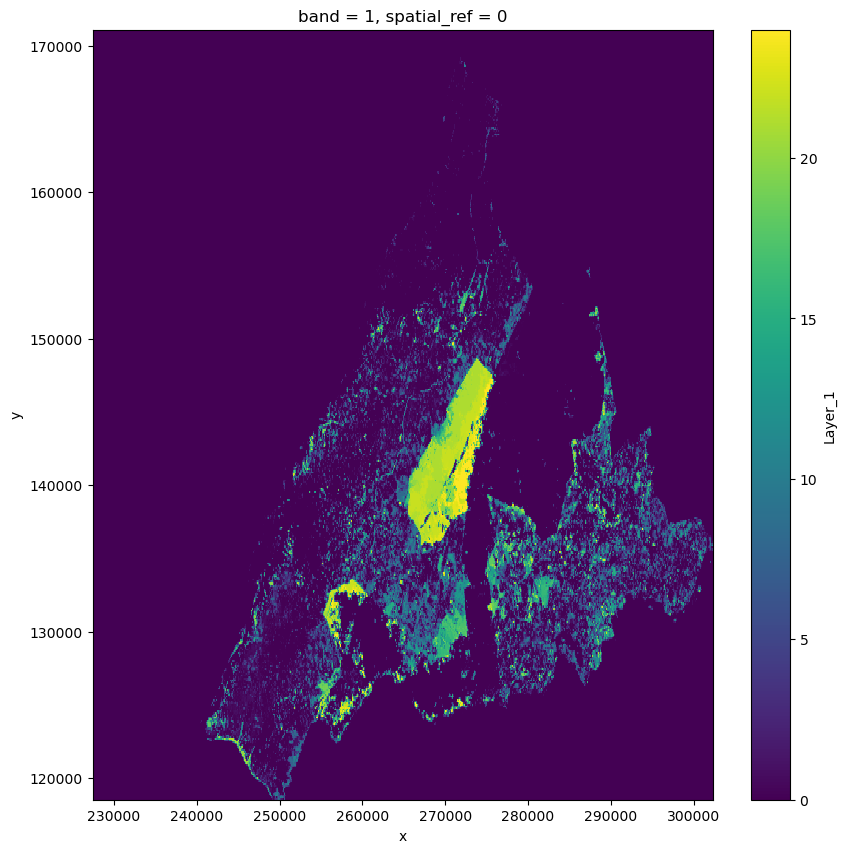

In [5]:
hansen.squeeze().coarsen(x=4, y=4, boundary='trim').mean().plot(figsize=(10, 10))

## KPI generation

In [13]:
import rioxarray as rxr
import geopandas as gpd
import numpy as np

# Load data
county = gpd.read_file("/home/georg/data/LEON_P6_forest-agri-change/County/counties_bugoma_32636.gpkg")
hansen = rxr.open_rasterio("/home/georg/data/LEON_P6_forest-agri-change/Hansen/hansen_bugoma_32636.tif")
forest_mask = rxr.open_rasterio("/home/georg/data/LEON_P6_forest-agri-change/forest_extent_bugoma_2020_32636.tif")

# DEBUG: Check what's going on
print("County CRS:", county.crs)
print("Hansen CRS:", hansen.rio.crs)
print("Forest CRS:", forest_mask.rio.crs)
print("\nCounty bounds:", county.total_bounds)
print("Hansen bounds:", hansen.rio.bounds())
print("Forest bounds:", forest_mask.rio.bounds())
print("\nCounty columns:", county.columns.tolist())
print("\nCounty data:")
print(county[['geometry']])  # show first few columns

County CRS: EPSG:32636
Hansen CRS: EPSG:32636
Forest CRS: EPSG:32636

County bounds: [227399.06290759 118461.5399916  302272.39527276 171109.80096332]
Hansen bounds: (227399.0629075911, 118461.53999160013, 302272.39527276, 171109.80096331757)
Forest bounds: (227379.60242133267, 118418.18118214462, 302300.96045518044, 171146.53172168267)

County columns: ['Shape_Leng', 'Shape_Area', 'ADM4_EN', 'ADM4_PCODE', 'ADM4_REF', 'ADM4ALT1EN', 'ADM4ALT2EN', 'ADM3_EN', 'ADM3_PCODE', 'ADM2_EN', 'ADM2_PCODE', 'ADM1_EN', 'ADM1_PCODE', 'ADM0_EN', 'ADM0_PCODE', 'date', 'validOn', 'validTo', 'geometry']

County data:
                                            geometry
0  MULTIPOLYGON (((265291.752 171100.153, 268453....
1  MULTIPOLYGON (((239691.338 153478.457, 252424....


In [11]:
# Load data
county = gpd.read_file("/home/georg/data/LEON_P6_forest-agri-change/County/counties_bugoma_32636.gpkg")
hansen = rxr.open_rasterio("/home/georg/data/LEON_P6_forest-agri-change/Hansen/hansen_bugoma_32636.tif")
forest_mask = rxr.open_rasterio("/home/georg/data/LEON_P6_forest-agri-change/forest_extent_bugoma_2020_32636.tif")

# Get pixel area in hectares
pixel_area_ha = abs(hansen.rio.resolution()[0] * hansen.rio.resolution()[1]) / 10000

# Loop through each county
results = []
for idx, row in county.iterrows():
    name = row['ADM4_EN'] 
    geom = [row.geometry]
    
    # Clip to this county
    h_clip = hansen.rio.clip(geom, county.crs).squeeze()
    f_clip = forest_mask.rio.clip(geom, county.crs).squeeze()
    
    # KPI 0: Forest baseline (ha)
    forest_ha = (f_clip == 1).sum().values * pixel_area_ha
    
    # KPI 1: Forest loss 2021-2024 (ha) - Hansen codes: 21, 22, 23, 24
    loss_mask = (h_clip >= 21) & (h_clip <= 24) & (f_clip == 1)
    loss_ha = loss_mask.sum().values * pixel_area_ha
    
    # Deforestation rate
    defor_rate = (loss_ha / forest_ha * 100) if forest_ha > 0 else 0
    
    results.append({
        'County': name,
        'KPI_0_Forest_Baseline_ha': round(forest_ha, 2),
        'KPI_1_Loss_2021_2024_ha': round(loss_ha, 2),
        'KPI_1_Deforestation_Rate_%': round(defor_rate, 2)
    })

# Display results
import pandas as pd
df = pd.DataFrame(results)
print(df)
# df.to_csv('forest_kpis.csv', index=False)

/home/georg/python/miniconda3/envs/geo/lib/python3.11/site-packages/xarray/core/duck_array_ops.py:215: RuntimeWarning: invalid value encountered in cast
  return data.astype(dtype, **kwargs)
/home/georg/python/miniconda3/envs/geo/lib/python3.11/site-packages/xarray/core/duck_array_ops.py:215: RuntimeWarning: invalid value encountered in cast
  return data.astype(dtype, **kwargs)


      County  KPI_0_Forest_Baseline_ha  KPI_1_Loss_2021_2024_ha  \
0    Kabwoya                 240730.84                      0.0   
1  Kyangwali                 100680.13                      0.0   

   KPI_1_Deforestation_Rate_%  
0                         0.0  
1                         0.0  


In [15]:
import rioxarray as rxr
import geopandas as gpd
import numpy as np
import pandas as pd

# Load data
county = gpd.read_file("/home/georg/data/LEON_P6_forest-agri-change/County/counties_bugoma_32636.gpkg")
hansen = rxr.open_rasterio("/home/georg/data/LEON_P6_forest-agri-change/Hansen/hansen_bugoma_32636.tif")
forest_mask = rxr.open_rasterio("/home/georg/data/LEON_P6_forest-agri-change/forest_extent_bugoma_2020_32636.tif")

# Check resolutions
print("Hansen resolution:", hansen.rio.resolution())
print("Forest resolution:", forest_mask.rio.resolution())

# Resample forest_mask to match Hansen
forest_mask = forest_mask.rio.reproject_match(hansen)

print("\nAfter resampling:")
print("Hansen shape:", hansen.shape)
print("Forest shape:", forest_mask.shape)

# Get pixel area from Hansen (since we're using its grid)
pixel_area_ha = abs(hansen.rio.resolution()[0] * hansen.rio.resolution()[1]) / 10000

# Loop through each county
results = []
for idx, row in county.iterrows():
    name = row['ADM4_EN']
    geom = [row.geometry]
    
    print(f"\nProcessing: {name}")
    
    # Clip to this county
    h_clip = hansen.rio.clip(geom, county.crs, drop=False)
    f_clip = forest_mask.rio.clip(geom, county.crs, drop=False)
    
    if h_clip.size == 0 or f_clip.size == 0:
        print(f"  WARNING: Empty clip for {name}")
        continue
    
    # Get data (first band)
    h_data = h_clip.values[0]
    f_data = f_clip.values[0]
    
    # KPI 0: Forest baseline (ha)
    forest_ha = (f_data == 1).sum() * pixel_area_ha
    
    # KPI 1: Forest loss 2021-2024
    loss_mask = (h_data >= 21) & (h_data <= 24) & (f_data == 1)
    loss_ha = loss_mask.sum() * pixel_area_ha
    
    # Annual deforestation rate
    years = 4
    defor_rate_annual = (loss_ha / years / forest_ha * 100) if forest_ha > 0 else 0
    
    print(f"  Forest: {forest_ha:.2f} ha, Loss: {loss_ha:.2f} ha, Rate: {defor_rate_annual:.3f}% yr⁻¹")
    
    results.append({
        'County': name,
        'KPI_0_Forest_Baseline_2020_ha': round(forest_ha, 2),
        'KPI_1_Loss_2021_2024_ha': round(loss_ha, 2),
        'KPI_1_Deforestation_Rate_pct_yr': round(defor_rate_annual, 3)
    })

# Display results
df = pd.DataFrame(results)
print("\n" + "="*60)
print(df.to_string(index=False))
df.to_csv('forest_kpis.csv', index=False)
print("\nSaved to forest_kpis.csv")

Hansen resolution: (27.730863838951443, -27.738809784888012)
Forest resolution: (9.978870276218398, -9.978870276218402)

After resampling:
Hansen shape: (1, 1898, 2700)
Forest shape: (1, 1898, 2700)

Processing: Kabwoya
  Forest: 31167.00 ha, Loss: 3057.50 ha, Rate: 2.453% yr⁻¹

Processing: Kyangwali
  Forest: 13034.38 ha, Loss: 4388.02 ha, Rate: 8.416% yr⁻¹

   County  KPI_0_Forest_Baseline_2020_ha  KPI_1_Loss_2021_2024_ha  KPI_1_Deforestation_Rate_pct_yr
  Kabwoya                       31167.00                  3057.50                            2.453
Kyangwali                       13034.38                  4388.02                            8.416

Saved to forest_kpis.csv


/home/georg/python/miniconda3/envs/geo/lib/python3.11/site-packages/xarray/core/duck_array_ops.py:215: RuntimeWarning: invalid value encountered in cast
  return data.astype(dtype, **kwargs)
/home/georg/python/miniconda3/envs/geo/lib/python3.11/site-packages/xarray/core/duck_array_ops.py:215: RuntimeWarning: invalid value encountered in cast
  return data.astype(dtype, **kwargs)


In [21]:
# Calculate KPIs per county
results = []
for idx, row in county.iterrows():
    h = hansen.rio.clip([row.geometry], county.crs).values[0]
    f = forest_mask.rio.clip([row.geometry], county.crs).values[0]
    
    forest_ha = (f == 1).sum() * pixel_area_ha
    
    # Loss per year
    loss_2021 = ((h == 21) & (f == 1)).sum() * pixel_area_ha
    loss_2022 = ((h == 22) & (f == 1)).sum() * pixel_area_ha
    loss_2023 = ((h == 23) & (f == 1)).sum() * pixel_area_ha
    loss_2024 = ((h == 24) & (f == 1)).sum() * pixel_area_ha
    total_loss = loss_2021 + loss_2022 + loss_2023 + loss_2024
    
    results.append({
        'County': row['ADM4_EN'],
        'Forest_2020_ha': round(forest_ha, 2),
        'Loss_2021_ha': round(loss_2021, 2),
        'Loss_2022_ha': round(loss_2022, 2),
        'Loss_2023_ha': round(loss_2023, 2),
        'Loss_2024_ha': round(loss_2024, 2),
        'Total_Loss_ha': round(total_loss, 2),
        'Rate_2021_%': round(loss_2021 / forest_ha * 100, 3) if forest_ha > 0 else 0,
        'Rate_2022_%': round(loss_2022 / forest_ha * 100, 3) if forest_ha > 0 else 0,
        'Rate_2023_%': round(loss_2023 / forest_ha * 100, 3) if forest_ha > 0 else 0,
        'Rate_2024_%': round(loss_2024 / forest_ha * 100, 3) if forest_ha > 0 else 0,
        'Avg_Rate_%/yr': round(total_loss / 4 / forest_ha * 100, 3) if forest_ha > 0 else 0
    })

# Save
df = pd.DataFrame(results)
print(df)
df.to_csv('forest_kpis_yearly.csv', index=False)

      County  Forest_2020_ha  Loss_2021_ha  Loss_2022_ha  Loss_2023_ha  \
0    Kabwoya        31167.00       1239.06        856.60        205.54   
1  Kyangwali        13034.38       1361.98       1601.36        572.92   

   Loss_2024_ha  Total_Loss_ha  Rate_2021_%  Rate_2022_%  Rate_2023_%  \
0        756.30        3057.50        3.976        2.748        0.659   
1        851.76        4388.02       10.449       12.286        4.395   

   Rate_2024_%  Avg_Rate_%/yr  
0        2.427          2.453  
1        6.535          8.416  


/home/georg/python/miniconda3/envs/geo/lib/python3.11/site-packages/xarray/core/duck_array_ops.py:215: RuntimeWarning: invalid value encountered in cast
  return data.astype(dtype, **kwargs)
/home/georg/python/miniconda3/envs/geo/lib/python3.11/site-packages/xarray/core/duck_array_ops.py:215: RuntimeWarning: invalid value encountered in cast
  return data.astype(dtype, **kwargs)


In [ ]:
crop = rxr.open_rasterio("/home/georg/data/LEON_P6_forest-agri-change/Crops/meancrops_24-25_32636.tif")
crop_01 = crop.where(crop > 0.1)

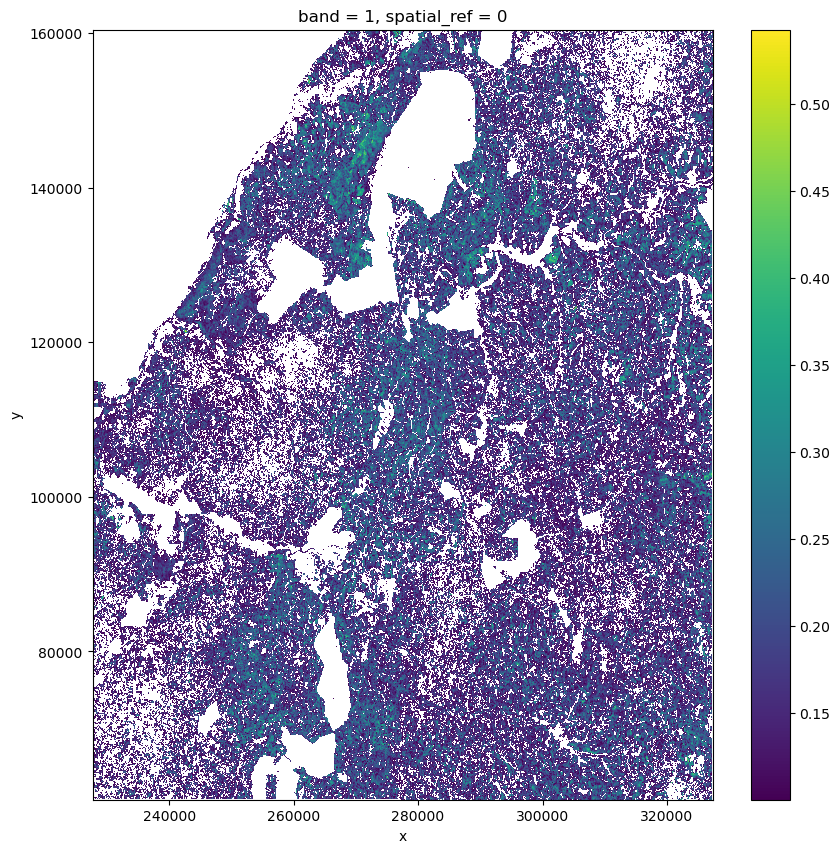

In [25]:
crop_01.squeeze().plot(figsize=(10, 10))

In [ ]:
# Load data
county = gpd.read_file("/home/georg/data/LEON_P6_forest-agri-change/County/counties_bugoma_32636.gpkg")
hansen = rxr.open_rasterio("/home/georg/data/LEON_P6_forest-agri-change/Hansen/hansen_bugoma_32636.tif")
forest_mask = rxr.open_rasterio("/home/georg/data/LEON_P6_forest-agri-change/forest_extent_bugoma_2020_32636.tif")
crop = rxr.open_rasterio("/home/georg/data/LEON_P6_forest-agri-change/Crops/meancrops_24-25_32636.tif")


# Align all grids to Hansen
forest_mask = forest_mask.rio.reproject_match(hansen)
crop = crop.rio.reproject_match(hansen)
pixel_area_ha = abs(hansen.rio.resolution()[0] * hansen.rio.resolution()[1]) / 10000

# Calculate KPIs per county
results = []
for idx, row in county.iterrows():
    h = hansen.rio.clip([row.geometry], county.crs).values[0]
    f = forest_mask.rio.clip([row.geometry], county.crs).values[0]
    c = crop.rio.clip([row.geometry], county.crs).values[0]  # Clip crop too!
    
    forest_ha = (f == 1).sum() * pixel_area_ha
    
    # Total forest loss 2021-2024
    loss_mask = (h >= 21) & (h <= 24) & (f == 1)
    total_loss_ha = loss_mask.sum() * pixel_area_ha
    
    # KPI 2: Loss that became cropland (crop > 0.1)
    loss_to_crop_mask = loss_mask & (c > 0.1)
    loss_to_crop_ha = loss_to_crop_mask.sum() * pixel_area_ha
    
    # Ratio
    crop_ratio = (loss_to_crop_ha / total_loss_ha * 100) if total_loss_ha > 0 else 0
    
    results.append({
        'County': row['ADM4_EN'],
        'Forest_2020_ha': round(forest_ha, 2),
        'Total_Loss_ha': round(total_loss_ha, 2),
        'Loss_to_Crop_ha': round(loss_to_crop_ha, 2),
        'KPI_2_Forest_to_Crop_%': round(crop_ratio, 2)
    })

# # Save
# df = pd.DataFrame(results)
# print(df)
# df.to_csv('forest_kpis_with_crop.csv', index=False)

      County  Forest_2020_ha  Total_Loss_ha  Loss_to_Crop_ha  \
0    Kabwoya        31167.00        3057.50          2346.36   
1  Kyangwali        13034.38        4388.02          3114.42   

   KPI_2_Forest_to_Crop_%  
0                   76.74  
1                   70.98  


/home/georg/python/miniconda3/envs/geo/lib/python3.11/site-packages/xarray/core/duck_array_ops.py:215: RuntimeWarning: invalid value encountered in cast
  return data.astype(dtype, **kwargs)
/home/georg/python/miniconda3/envs/geo/lib/python3.11/site-packages/xarray/core/duck_array_ops.py:215: RuntimeWarning: invalid value encountered in cast
  return data.astype(dtype, **kwargs)


In [29]:
import rioxarray as rxr
import geopandas as gpd
import pandas as pd

# Load data
county = gpd.read_file("/home/georg/data/LEON_P6_forest-agri-change/County/counties_bugoma_32636.gpkg")
hansen = rxr.open_rasterio("/home/georg/data/LEON_P6_forest-agri-change/Hansen/hansen_bugoma_32636.tif")
forest_mask = rxr.open_rasterio("/home/georg/data/LEON_P6_forest-agri-change/forest_extent_bugoma_2020_32636.tif")
crop = rxr.open_rasterio("/home/georg/data/LEON_P6_forest-agri-change/Crops/meancrops_24-25_32636.tif")

# Align all grids to Hansen
forest_mask = forest_mask.rio.reproject_match(hansen)
crop = crop.rio.reproject_match(hansen)
pixel_area_ha = abs(hansen.rio.resolution()[0] * hansen.rio.resolution()[1]) / 10000

# Calculate KPIs per county
results = []
for idx, row in county.iterrows():
    h = hansen.rio.clip([row.geometry], county.crs).values[0]
    f = forest_mask.rio.clip([row.geometry], county.crs).values[0]
    c = crop.rio.clip([row.geometry], county.crs).values[0]
    
    forest_ha = (f == 1).sum() * pixel_area_ha
    
    # Calculate for each year
    data = {'County': row['ADM4_EN'], 'Forest_2020_ha': round(forest_ha, 2)}
    
    for year in [21, 22, 23, 24]:
        loss_mask = (h == year) & (f == 1)
        loss_ha = loss_mask.sum() * pixel_area_ha
        
        loss_to_crop_ha = (loss_mask & (c > 0.1)).sum() * pixel_area_ha
        crop_pct = (loss_to_crop_ha / loss_ha * 100) if loss_ha > 0 else 0
        
        data[f'Loss_20{year}_ha'] = round(loss_ha, 2)
        data[f'Crop_20{year}_ha'] = round(loss_to_crop_ha, 2)
        data[f'Crop_20{year}_%'] = round(crop_pct, 2)
    
    # Totals
    total_loss = sum(data[f'Loss_20{y}_ha'] for y in [21, 22, 23, 24])
    total_crop = sum(data[f'Crop_20{y}_ha'] for y in [21, 22, 23, 24])
    
    data['Total_Loss_ha'] = round(total_loss, 2)
    data['Total_Crop_ha'] = round(total_crop, 2)
    data['KPI_2_Total_Crop_%'] = round((total_crop / total_loss * 100) if total_loss > 0 else 0, 2)
    
    results.append(data)

# Save
df = pd.DataFrame(results)
print(df)
# df.to_csv('forest_kpis_yearly_crop.csv', index=False)

/home/georg/python/miniconda3/envs/geo/lib/python3.11/site-packages/xarray/core/duck_array_ops.py:215: RuntimeWarning: invalid value encountered in cast
  return data.astype(dtype, **kwargs)
/home/georg/python/miniconda3/envs/geo/lib/python3.11/site-packages/xarray/core/duck_array_ops.py:215: RuntimeWarning: invalid value encountered in cast
  return data.astype(dtype, **kwargs)


      County  Forest_2020_ha  Loss_2021_ha  Crop_2021_ha  Crop_2021_%  \
0    Kabwoya        31167.00       1239.06       1153.83        93.12   
1  Kyangwali        13034.38       1361.98       1210.06        88.85   

   Loss_2022_ha  Crop_2022_ha  Crop_2022_%  Loss_2023_ha  Crop_2023_ha  \
0        856.60        757.99        88.49        205.54        154.23   
1       1601.36       1216.37        75.96        572.92        325.77   

   Crop_2023_%  Loss_2024_ha  Crop_2024_ha  Crop_2024_%  Total_Loss_ha  \
0        75.04        756.30        280.30        37.06        3057.50   
1        56.86        851.76        362.23        42.53        4388.02   

   Total_Crop_ha  KPI_2_Total_Crop_%  
0        2346.35               76.74  
1        3114.43               70.98  


### KPI3 Frontier Hotspot

In [30]:
from scipy.ndimage import binary_dilation, binary_erosion

# Load data
county = gpd.read_file("/home/georg/data/LEON_P6_forest-agri-change/County/counties_bugoma_32636.gpkg")
hansen = rxr.open_rasterio("/home/georg/data/LEON_P6_forest-agri-change/Hansen/hansen_bugoma_32636.tif")
forest_mask = rxr.open_rasterio("/home/georg/data/LEON_P6_forest-agri-change/forest_extent_bugoma_2020_32636.tif")

# Align grids
forest_mask = forest_mask.rio.reproject_match(hansen)
pixel_size = abs(hansen.rio.resolution()[0])  # meters
pixel_area_ha = (pixel_size ** 2) / 10000

# Calculate buffer in pixels (1 km = 1000 m)
buffer_pixels = int(1000 / pixel_size)

# KPI 3: Frontier pressure
results = []
for idx, row in county.iterrows():
    h = hansen.rio.clip([row.geometry], county.crs).values[0]
    f = forest_mask.rio.clip([row.geometry], county.crs).values[0]
    
    # Find forest edge (pixels that are forest AND adjacent to non-forest)
    forest_binary = (f == 1)
    eroded = binary_erosion(forest_binary)
    edge = forest_binary & ~eroded  # Edge pixels
    
    # Create 1 km buffer around edge
    buffer_zone = binary_dilation(edge, iterations=buffer_pixels)
    
    # Forest loss within buffer zone (2021-2024)
    loss_mask = (h >= 21) & (h <= 24) & (f == 1)
    loss_in_buffer = loss_mask & buffer_zone
    loss_buffer_ha = loss_in_buffer.sum() * pixel_area_ha
    
    # Calculate edge length in km
    edge_pixels = edge.sum()
    edge_km = edge_pixels * pixel_size / 1000
    
    # KPI 3: Frontier pressure (ha/km)
    frontier_pressure = loss_buffer_ha / edge_km if edge_km > 0 else 0
    
    results.append({
        'County': row['ADM4_EN'],
        'Edge_Length_km': round(edge_km, 2),
        'Loss_in_1km_Buffer_ha': round(loss_buffer_ha, 2),
        'KPI_3_Frontier_Pressure_ha_per_km': round(frontier_pressure, 2)
    })

# Save
df = pd.DataFrame(results)
print(df)
# df.to_csv('frontier_pressure.csv', index=False)

/home/georg/python/miniconda3/envs/geo/lib/python3.11/site-packages/xarray/core/duck_array_ops.py:215: RuntimeWarning: invalid value encountered in cast
  return data.astype(dtype, **kwargs)
/home/georg/python/miniconda3/envs/geo/lib/python3.11/site-packages/xarray/core/duck_array_ops.py:215: RuntimeWarning: invalid value encountered in cast
  return data.astype(dtype, **kwargs)


      County  Edge_Length_km  Loss_in_1km_Buffer_ha  \
0    Kabwoya          768.56                2144.28   
1  Kyangwali          555.28                3868.77   

   KPI_3_Frontier_Pressure_ha_per_km  
0                               2.79  
1                               6.97  


In [20]:
import numpy as np
import pandas as pd
import geopandas as gpd
import rioxarray as rxr
from scipy.ndimage import binary_erosion, binary_dilation
from scipy.signal import convolve2d

# -------------------------
# USER PATHS
# -------------------------
COUNTY_PATH = "/home/georg/data/LEON_P6_forest-agri-change/County/counties_bugoma_32636.gpkg"
HANSEN_PATH = "/home/georg/data/LEON_P6_forest-agri-change/Hansen/hansen_bugoma_32636.tif"
FOREST_PATH = "/home/georg/data/LEON_P6_forest-agri-change/forest_extent_bugoma_2020_32636.tif"
CROP_PATH   = "/home/georg/data/LEON_P6_forest-agri-change/Crops/meancrops_24-25_32636.tif"

YEARS = [21, 22, 23, 24]  # Hansen codes 21..24

# -------------------------
# HELPERS
# -------------------------
def circular_kernel(radius_pix: int) -> np.ndarray:
    """Normalized circular kernel with given radius in pixels."""
    r = int(max(1, radius_pix))
    y, x = np.ogrid[-r:r+1, -r:r+1]
    circle = (x*x + y*y) <= (r*r)
    k = circle.astype(np.float32)
    k /= k.sum()
    return k

def compute_forest_edge(forest_bin: np.ndarray) -> np.ndarray:
    """Edge = forest pixels adjacent to non-forest (binary erosion trick)."""
    eroded = binary_erosion(forest_bin, border_value=0)
    edge = forest_bin & (~eroded)
    return edge

def to2d(da):
    """Get a 2D numpy array from a 2D or 3D (band, y, x) DataArray."""
    v = da.values
    if v.ndim == 3:
        return v[0]
    return v

# -------------------------
# LOAD
# -------------------------
county = gpd.read_file(COUNTY_PATH)

hansen = rxr.open_rasterio(HANSEN_PATH)      # loss year codes (21..24 here)
forest = rxr.open_rasterio(FOREST_PATH)      # forest mask (1=forest)
crop   = rxr.open_rasterio(CROP_PATH)        # crop probability/score (0..1)

# Align forest and crop to Hansen grid
forest = forest.rio.reproject_match(hansen)
crop   = crop.rio.reproject_match(hansen)

# 2D arrays
H_full = to2d(hansen)
F_full = (to2d(forest) == 1)        # binary forest mask
C_full = (to2d(crop) > 0.1)         # crop presence threshold

# Pixel metrics
pixel = abs(hansen.rio.resolution()[0])      # meters (assume square pixels)
pixel_area_ha = (pixel**2) / 10000.0
radius_m = 1000
radius_pix = max(1, int(round(radius_m / pixel)))

# Edge buffer distance (1 km)
buffer_pix = radius_pix

# Circular kernel for 1 km neighborhood density
K = circular_kernel(radius_pix)

# -------------------------
# 1) FRONTIER HOTSPOT MAPS (1 km circular density)
# loss_density_1km[year]           : fraction of loss within 1 km
# loss_to_crop_density_1km[year]   : fraction of loss->crop within 1 km
# -------------------------
loss_density_1km = {}
loss_to_crop_density_1km = {}

for y in YEARS:
    loss_y = (H_full == y).astype(np.float32)            # 0/1 loss in year y
    loss_to_crop_y = (loss_y * C_full.astype(np.float32)) # 0/1 loss->crop

    # Density (fraction in 1 km circle) via circular convolution
    dens_loss = convolve2d(loss_y, K, mode="same", boundary="symm")
    dens_loss_to_crop = convolve2d(loss_to_crop_y, K, mode="same", boundary="symm")

    loss_density_1km[y] = dens_loss
    loss_to_crop_density_1km[y] = dens_loss_to_crop

# -------------------------
# 2) KPI 3 – FRONTIER PRESSURE (by county × year)
#   - Pressure_all  = Σ loss ha within 1 km of forest edge / edge km
#   - Pressure_crop = Σ (loss->crop) ha within 1 km of forest edge / edge km
#   - Share_crop    = Pressure_crop / Pressure_all
# -------------------------
results = []
name_col = "ADM4_EN" if "ADM4_EN" in county.columns else county.columns[0]

for _, row in county.iterrows():
    geom = [row.geometry]

    # Clip all layers to county
    H = to2d(hansen.rio.clip(geom, county.crs, drop=False))
    F = (to2d(forest.rio.clip(geom, county.crs, drop=False)) == 1)
    C = (to2d(crop.rio.clip(geom, county.crs, drop=False)) > 0.1)

    # Edge & 1 km edge buffer
    edge = compute_forest_edge(F)
    edge_buffer = binary_dilation(edge, iterations=buffer_pix)

    # Edge length (km): count of edge pixels * pixel size
    edge_km = (edge.sum() * pixel) / 1000.0
    if edge_km == 0:
        # avoid division by zero; still compute zeros for this county
        edge_km = 0.0

    for y in YEARS:
        loss_y = (H == y)
        # Inside forest edge buffer AND original forest area (to ensure it's a forest loss)
        loss_near_edge = loss_y & edge_buffer & F
        loss_to_crop_near_edge = loss_near_edge & C

        # Areas (ha)
        loss_ha_all = loss_near_edge.sum() * pixel_area_ha
        loss_ha_crop = loss_to_crop_near_edge.sum() * pixel_area_ha

        # KPIs
        pressure_all = (loss_ha_all / edge_km) if edge_km > 0 else 0.0
        pressure_crop = (loss_ha_crop / edge_km) if edge_km > 0 else 0.0
        share_crop = (pressure_crop / pressure_all) if pressure_all > 0 else np.nan

        results.append({
            "County": row[name_col],
            "Year": y,
            "Edge_km": round(edge_km, 3),
            "Loss_ha_in_1km_edge_all": round(float(loss_ha_all), 3),
            "Loss_ha_in_1km_edge_crop": round(float(loss_ha_crop), 3),
            "Pressure_all_ha_per_km": round(float(pressure_all), 3),
            "Pressure_crop_ha_per_km": round(float(pressure_crop), 3),
            "Share_crop_of_pressure": None if np.isnan(share_crop) else round(float( share_crop), 3),
        })

kpi_df = pd.DataFrame(results).sort_values(["County", "Year"])

# -------------------------
# DEBUG/INSPECTION EXAMPLES (no export)
# -------------------------
print("Years processed:", YEARS)
print("loss_density_1km keys:", list(loss_density_1km.keys()))
print("kpi_df preview:")
print(kpi_df.head())

# Access arrays, e.g.:
# loss_density_1km[21].shape
# loss_to_crop_density_1km[24].max()

# kpi_df contains per-county KPIs (all vs crop) for 21..24

/home/georg/python/miniconda3/envs/geo/lib/python3.11/site-packages/xarray/core/duck_array_ops.py:215: RuntimeWarning: invalid value encountered in cast
  return data.astype(dtype, **kwargs)


Years processed: [21, 22, 23, 24]
loss_density_1km keys: [21, 22, 23, 24]
kpi_df preview:
      County  Year  Edge_km  Loss_ha_in_1km_edge_all  \
0    Kabwoya    21  768.561                  710.326   
1    Kabwoya    22  768.561                  637.348   
2    Kabwoya    23  768.561                  195.096   
3    Kabwoya    24  768.561                  601.512   
4  Kyangwali    21  555.283                 1167.497   

   Loss_ha_in_1km_edge_crop  Pressure_all_ha_per_km  Pressure_crop_ha_per_km  \
0                   634.964                   0.924                    0.826   
1                   541.607                   0.829                    0.705   
2                   143.957                   0.254                    0.187   
3                   234.161                   0.783                    0.305   
4                  1028.077                   2.103                    1.851   

   Share_crop_of_pressure  
0                   0.894  
1                   0.850  
2       

/home/georg/python/miniconda3/envs/geo/lib/python3.11/site-packages/xarray/core/duck_array_ops.py:215: RuntimeWarning: invalid value encountered in cast
  return data.astype(dtype, **kwargs)


In [21]:
kpi_df

,County,Year,Edge_km,Loss_ha_in_1km_edge_all,Loss_ha_in_1km_edge_crop,Pressure_all_ha_per_km,Pressure_crop_ha_per_km,Share_crop_of_pressure
0,Kabwoya,21,768.561,710.326,634.964,0.924,0.826,0.894
1,Kabwoya,22,768.561,637.348,541.607,0.829,0.705,0.850
2,Kabwoya,23,768.561,195.096,143.957,0.254,0.187,0.738
3,Kabwoya,24,768.561,601.512,234.161,0.783,0.305,0.389
4,Kyangwali,21,555.283,1167.497,1028.077,2.103,1.851,0.881
5,Kyangwali,22,555.283,1341.676,986.705,2.416,1.777,0.735
6,Kyangwali,23,555.283,547.529,324.518,0.986,0.584,0.593
7,Kyangwali,24,555.283,812.065,362.122,1.462,0.652,0.446


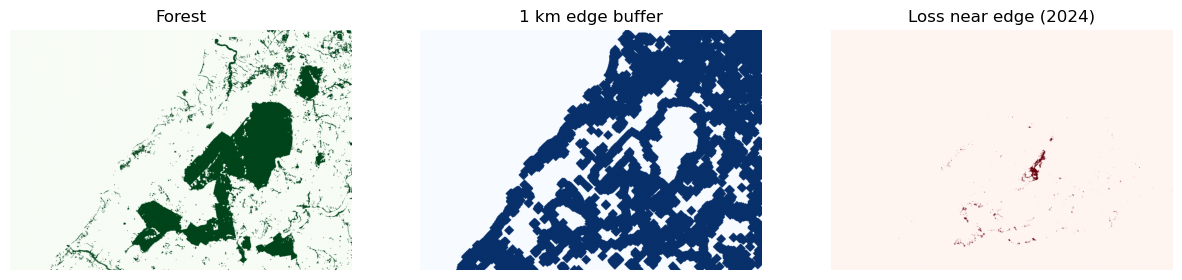

In [29]:
# Recompute on full grid once (or use any county subset if you prefer)
from scipy.ndimage import binary_erosion, binary_dilation

F = F_full
edge = binary_erosion(F, border_value=0) ^ F  # equivalent to forest & ~eroded
edge_buffer = binary_dilation(edge, iterations=radius_pix)

loss24 = (H_full == 24)
loss24_near_edge = loss24 & edge_buffer & F

fig, axs = plt.subplots(1, 3, figsize=(15, 5))
axs[0].imshow(F, cmap="Greens"); axs[0].set_title("Forest")
axs[1].imshow(edge_buffer, cmap="Blues"); axs[1].set_title("1 km edge buffer")
axs[2].imshow(loss24_near_edge, cmap="Reds"); axs[2].set_title("Loss near edge (2024)")
for ax in axs: ax.axis("off")
plt.show()

Text(0.5, 1.0, 'Loss near edge (2024)')

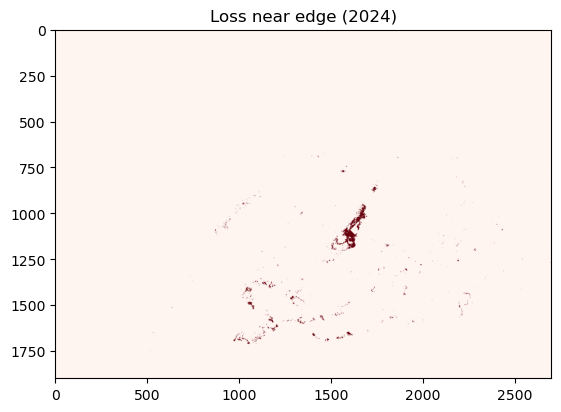

In [ ]:
plt.imshow(loss24_near_edge, cmap="Reds"); plt.title("Loss near edge (2024)") 

Map saved to: frontier_pressure_map_v2.png


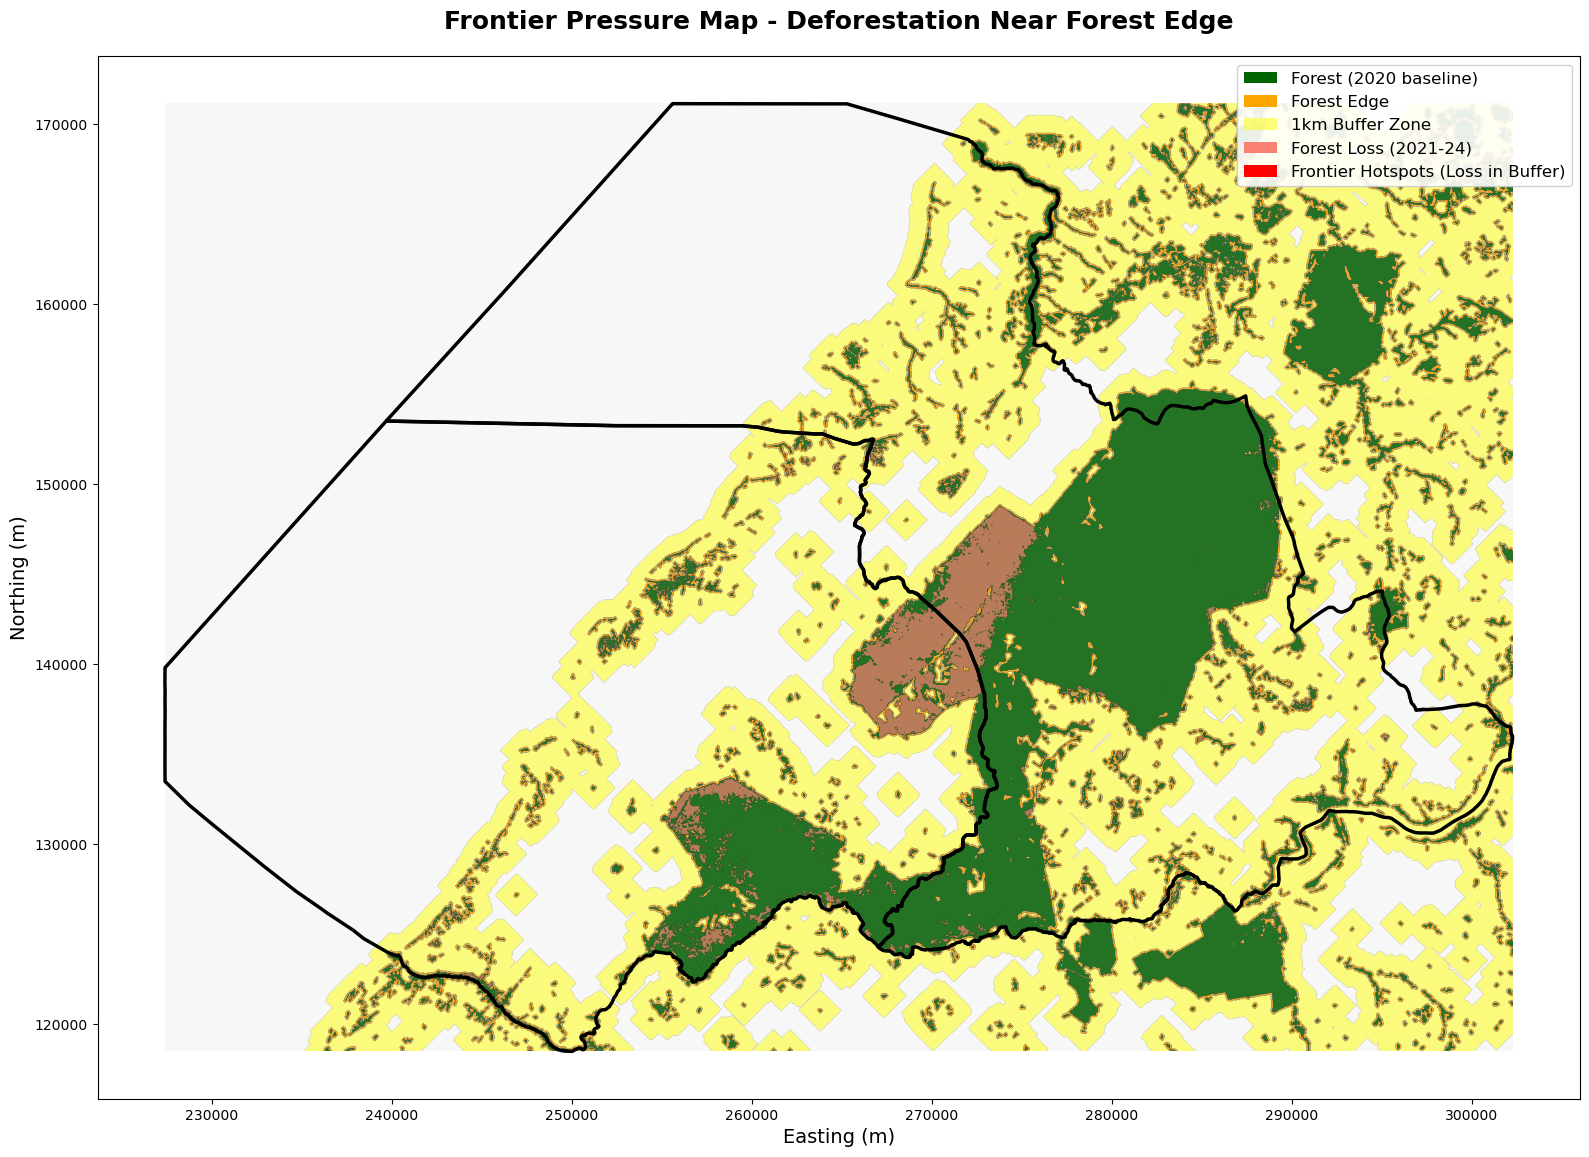

In [ ]:
import rioxarray as rxr
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import binary_dilation, binary_erosion, generic_filter
from matplotlib.colors import ListedColormap

# Load data
county = gpd.read_file("/home/georg/data/LEON_P6_forest-agri-change/County/counties_bugoma_32636.gpkg")
hansen = rxr.open_rasterio("/home/georg/data/LEON_P6_forest-agri-change/Hansen/hansen_bugoma_32636.tif")
forest_mask = rxr.open_rasterio("/home/georg/data/LEON_P6_forest-agri-change/forest_extent_bugoma_2020_32636.tif")

# Align grids
forest_mask = forest_mask.rio.reproject_match(hansen)
pixel_size = abs(hansen.rio.resolution()[0])
buffer_pixels = int(1000 / pixel_size)

# Get data
h = hansen.values[0]
f = forest_mask.values[0]

# Forest and loss
forest_binary = (f == 1)
loss_mask = (h >= 21) & (h <= 24) & (f == 1)

# Better edge detection: forest pixels adjacent to non-forest
# Dilate forest, then edge = dilated - forest
dilated_forest = binary_dilation(forest_binary, iterations=3)
edge = dilated_forest & ~forest_binary  # 3-pixel thick edge outside forest

# 1km buffer from edge (going outward)
buffer_zone = binary_dilation(edge, iterations=buffer_pixels) & ~dilated_forest

# Loss in buffer zone
loss_in_buffer = loss_mask & buffer_zone

# Create layered map
fig, ax = plt.subplots(figsize=(16, 12))

# Base layer: all non-forest as light gray
base = np.ones_like(h, dtype=float) * 0.9
base[forest_binary] = 0

# Plot layers from bottom to top
ax.imshow(base, cmap='gray', vmin=0, vmax=1, alpha=0.3,
          extent=[hansen.x.min(), hansen.x.max(), hansen.y.min(), hansen.y.max()])

# Forest (green)
forest_display = np.ma.masked_where(~forest_binary, forest_binary)
ax.imshow(forest_display, cmap=ListedColormap(['darkgreen']), alpha=0.8,
          extent=[hansen.x.min(), hansen.x.max(), hansen.y.min(), hansen.y.max()])

# Buffer zone (yellow)
buffer_display = np.ma.masked_where(~buffer_zone, buffer_zone)
ax.imshow(buffer_display, cmap=ListedColormap(['yellow']), alpha=0.5,
          extent=[hansen.x.min(), hansen.x.max(), hansen.y.min(), hansen.y.max()])

# Forest edge (orange) - THICKER NOW
edge_display = np.ma.masked_where(~edge, edge)
ax.imshow(edge_display, cmap=ListedColormap(['orange']), alpha=0.9,
          extent=[hansen.x.min(), hansen.x.max(), hansen.y.min(), hansen.y.max()])

# ALL forest loss (light red)
loss_display = np.ma.masked_where(~loss_mask, loss_mask)
ax.imshow(loss_display, cmap=ListedColormap(['salmon']), alpha=0.7,
          extent=[hansen.x.min(), hansen.x.max(), hansen.y.min(), hansen.y.max()])

# Frontier hotspots (bright red) - LOSS IN BUFFER
hotspot_display = np.ma.masked_where(~loss_in_buffer, loss_in_buffer)
ax.imshow(hotspot_display, cmap=ListedColormap(['red']), alpha=1.0,
          extent=[hansen.x.min(), hansen.x.max(), hansen.y.min(), hansen.y.max()])

# County boundaries
county.boundary.plot(ax=ax, color='black', linewidth=2.5)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='darkgreen', label='Forest (2020 baseline)'),
    Patch(facecolor='orange', label='Forest Edge'),
    Patch(facecolor='yellow', alpha=0.5, label='1km Buffer Zone'),
    Patch(facecolor='salmon', label='Forest Loss (2021-24)'),
    Patch(facecolor='red', label='Frontier Hotspots (Loss in Buffer)')
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=12, framealpha=0.9)

ax.set_title('Frontier Pressure Map - Deforestation Near Forest Edge', 
             fontsize=18, fontweight='bold', pad=20)
ax.set_xlabel('Easting (m)', fontsize=14)
ax.set_ylabel('Northing (m)', fontsize=14)

plt.tight_layout()
plt.savefig('frontier_pressure_map_v2.png', dpi=300, bbox_inches='tight')
print("Map saved to: frontier_pressure_map_v2.png")
plt.show()